# Assignment 1

Suppressing all FutureWarnings to enhance code readibility

https://saturncloud.io/blog/how-to-suppress-pandas-future-warning-a-guide-for-data-scientists/#:~:text=Method%201%3A%20Using%20the%20Warnings%20Module&text=In%20this%20example%2C%20we%20import,FutureWarning%20messages%20generated%20by%20Pandas.

In [143]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. Understanding the Dataset

**Explore the Data**: 

- Explore the dataset and understand the problem statement.- 
Identify the independent and dependent variables
- 
Briefly explain why classification is the appropriate machine learning category for this problem.

The following link was used to help with exploring and understanding the data:
https://datacarpentry.org/python-ecology-lesson/02-starting-with-data.html

In [144]:
import pandas as pd
from IPython.display import display

In [145]:
df = pd.read_csv("C:/Users/skenne26/OneDrive - UHG/Myfolder/12_MSc/CT5170_PrinciplesOfMachineLearning/Assignment1/Perinatal Risk Information-1.csv")

In [146]:
# Inspect the first few rows of the data
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Type
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [147]:
# Check to see what Data Structure we are provided with
type(df)

pandas.core.frame.DataFrame

In [148]:
# Assess what Data Types each column has
datatypes = df.dtypes
display(pd.DataFrame(datatypes).T)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,Type
0,int64,int64,int64,float64,float64,int64,object


In [149]:
# For the Object Data Type (in column 'Type'), check to see what the entries are
pd.unique(df['Type'])

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [150]:
# Use the describe method to get a description of the data frame
Type = df['Type'].describe()
Age = df['Age'].describe()
SystolicBP = df['SystolicBP'].describe()
DiastolicBP = df['DiastolicBP'].describe()
BS = df['BS'].describe()
BodyTemp = df['BodyTemp'].describe()
HeartRate = df['HeartRate'].describe()

The display function was used to more easily view the distribution of each variable. The following link helped in understanding how to use the display function:

https://www.geeksforgeeks.org/display-the-pandas-dataframe-in-table-style/

In [151]:
display(pd.DataFrame(Type).T)
display(pd.DataFrame(Age).T)
display(pd.DataFrame(SystolicBP).T)
display(pd.DataFrame(DiastolicBP).T)
display(pd.DataFrame(BS).T)
display(pd.DataFrame(BodyTemp).T)
display(pd.DataFrame(HeartRate).T)

,count,unique,top,freq
Type,1014,3,low risk,406


,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0


,count,mean,std,min,25%,50%,75%,max
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0


,count,mean,std,min,25%,50%,75%,max
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0


,count,mean,std,min,25%,50%,75%,max
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0


,count,mean,std,min,25%,50%,75%,max
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0


,count,mean,std,min,25%,50%,75%,max
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


### 2. Data Exploration and Pre-Processing

**Data Pre-Processing**:

- Analyze the distribution of data between the training and testing sets.
- 
Determine whether the dataset is imbalanced. Provide a brief explanation
- 
Perform data pre-processing, including handling missing values, feature scaling, and any necessary transformations. Explain why these steps are essential or not required.

Checking for missing values and outliers in each variable

https://miamioh.edu/centers-institutes/center-for-analytics-data-science/students/coding-tutorials/python/data-cleaning.html#:~:text=Next%2C%20we%20would%20like%20to,False%20for%20non%2Dmissing%20cells.

In [152]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
Type           0
dtype: int64

From the above we can see that there are no missing values in the data

From inspecting the results in Section 1 where we used .describe() to see the mean, min, max etc. of each variable, there seems to be an outlier in the HeartRate variable. There is at least one value of 7 which is very different to the mean. Using our intuition, we can deduce that this is an error, possibly due to a typo when the data was entered

In [153]:
display(pd.DataFrame(HeartRate).T)

,count,mean,std,min,25%,50%,75%,max
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


Replace this value with the mean value of 74

In [154]:
df['HeartRate']= df['HeartRate'].replace(7, 74)

In [155]:
HeartRate = df['HeartRate'].describe()
display(pd.DataFrame(HeartRate).T)

,count,mean,std,min,25%,50%,75%,max
HeartRate,1014.0,74.433925,7.514453,60.0,70.0,76.0,80.0,90.0


Now we can see above that the distribution of values is more reasonable and the outliers have been removed

**Distribution of Data**: 

Analyze the distribution of data between the training and testing sets

First, lets split the data into training and test sets as described in: 
https://www.geeksforgeeks.org/how-to-split-a-dataset-into-train-and-test-sets-using-python/

In [156]:
from sklearn.model_selection import train_test_split

In [157]:
# get the locations of X (independent) and y (dependent) variables
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# splitting train:test 
test_size =0.3

# split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0)

In [158]:
X_train.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
993,25,120,90,15.0,98.0,80
406,25,120,80,6.8,98.0,66
643,39,110,70,7.9,98.0,80
258,18,90,60,6.9,98.0,70
644,25,140,100,15.0,98.6,70


In [159]:
y_train.head()

993    high risk
406     mid risk
643     mid risk
258     low risk
644    high risk
Name: Type, dtype: object

**Summary Statistics**:

Look at some summary statistics for the Independent variables to see if they are similar in both training and test sets

In [160]:
# Calculate summary statistics
Train_summary = X_train.describe().loc[['mean', 'std','min', 'max']]
Test_summary = X_test.describe().loc[['mean', 'std','min', 'max']]

# Combine the summaries for comparison
summary = pd.concat([Train_summary, Test_summary], axis=1, keys=['Train_independent', 'Test_independent'])

# Print the combined summary
display(pd.DataFrame(summary))

Train_independent                                                 \
                   Age  SystolicBP DiastolicBP         BS    BodyTemp   
mean         30.256700  113.211566   76.361072   8.686883   98.676164   
std          13.633587   18.314664   13.744211   3.227994    1.376009   
min          10.000000   70.000000   49.000000   6.000000   98.000000   
max          70.000000  160.000000  100.000000  19.000000  103.000000   

                Test_independent                                     \
      HeartRate              Age  SystolicBP DiastolicBP         BS   
mean  74.568406        28.977049  113.167213   76.691803   8.816885   
std    7.536908        13.075041   18.639982   14.229675   3.444792   
min   60.000000        10.000000   70.000000   49.000000   6.000000   
max   90.000000        65.000000  160.000000  100.000000  19.000000   

                             
        BodyTemp  HeartRate  
mean   98.639344  74.121311  
std     1.362476   7.464943  
min    98.000000  60.000000  
max   103.000000  90.000000

Do the same for the dependent variable

In [161]:
# Calculate summary statistics, providing the % split of each category in the y dependent variables for both train and test sets
Train_summary =  pd.Series(y_train).value_counts(normalize=True)*100
Test_summary = pd.Series(y_test).value_counts(normalize=True)*100
All = pd.Series(df['Type']).value_counts(normalize=True)*100

# Combine the summaries for comparison
summary = pd.concat([All, Train_summary, Test_summary], axis=1, keys=['All', 'Train_dependent %', 'Test_dependent %'])

# Print the combined summary
display(pd.DataFrame(summary))

,All,Train_dependent %,Test_dependent %
Type,,,
low risk,40.039448,40.479549,39.016393
mid risk,33.136095,32.863188,33.770492
high risk,26.824458,26.657264,27.213115


In [162]:
# Calculate summary statistics, providing the counts  of each category in the y dependent variables for both train and test sets
Train_summary =  pd.Series(y_train).value_counts()
Test_summary = pd.Series(y_test).value_counts()
All = pd.Series(df['Type']).value_counts()

# Combine the summaries for comparison
summary = pd.concat([All, Train_summary, Test_summary], axis=1, keys=['All','Train_independent', 'Test_independent'])

# Print the combined summary
display(pd.DataFrame(summary))

,All,Train_independent,Test_independent
Type,,,
low risk,406,287,119
mid risk,336,233,103
high risk,272,189,83


We can use the above distribution to assess if the data set is imbalanced. For three categories, a 33.33% split in each category would represent a perfectly balanced distribution.

There is some element of imbalance since the low risk category has 40% split and the high risk category has a 27% split. However, this is only considered to be a slight to moderate level of imbalance.

**Kolmogorov-Smirnov Test**:

From the above independent and dependent variables, the distributions look similar. However, lets perform a statistical test to prove this.

Now perform a Kolmogorov-Smirnov, 2-sample test to perform a statistical comparison of the distributions of the train and tests sets for each variable. Under the Null Hypotheses, the distributions are the same. If the p-value <0.05 we will reject this null Hypothesis

https://stats.stackexchange.com/questions/354035/how-to-compare-the-data-distribution-of-2-datasets

https://www.statology.org/kolmogorov-smirnov-test-python/

In [163]:
from scipy.stats import ks_2samp
import numpy as np

In [164]:
# Age
age_train = X_train['Age']
age_test = X_test['Age']
Age_stats = ks_2samp(age_train, age_test)

# SystolicBP
SysBP_train = X_train['SystolicBP']
SysBP_test = X_test['SystolicBP']
SysBP_stats = ks_2samp(SysBP_train, SysBP_test)

# DiastolicBP
DiaBP_train = X_train['DiastolicBP']
DiaBP_test = X_test['DiastolicBP']
DiaBP_stats = ks_2samp(DiaBP_train, DiaBP_test)

# BS
BS_train = X_train['BS']
BS_test = X_test['BS']
BS_stats = ks_2samp(BS_train, BS_test)

# BodyTemp
BodyTemp_train = X_train['BodyTemp']
BodyTemp_test = X_test['BodyTemp']
BodyTemp_stats = ks_2samp(BodyTemp_train, BodyTemp_test)

# HeartRate
HeartRate_train = X_train['HeartRate']
HeartRate_test = X_test['HeartRate']
HeartRate_stats = ks_2samp(HeartRate_train, HeartRate_test)

# Type
Type_train = y_train
Type_test = y_test
Type_stats = ks_2samp(Type_train, Type_test)

In [165]:
Age_stats

KstestResult(statistic=0.07379592591736225, pvalue=0.18429974251392922, statistic_location=29, statistic_sign=-1)

In [166]:
SysBP_stats

KstestResult(statistic=0.017100973432911743, pvalue=0.9999998307824867, statistic_location=120, statistic_sign=1)

In [167]:
DiaBP_stats

KstestResult(statistic=0.03724479178709334, pvalue=0.9150605044715051, statistic_location=80, statistic_sign=1)

BS_stats

In [168]:
BodyTemp_stats

KstestResult(statistic=0.024569354204721495, pvalue=0.9990865045015689, statistic_location=100.0, statistic_sign=-1)

In [169]:
HeartRate_stats

KstestResult(statistic=0.06257254502994289, pvalue=0.3557098327967557, statistic_location=70, statistic_sign=-1)

In [170]:
Type_stats

KstestResult(statistic=0.009073042151263613, pvalue=1.0, statistic_location='low risk', statistic_sign=1)

Conclusion:

For all of the variables, both independent and dependent, the null hypothesis holds true and is not rejected since the p-value is >0.05. Therefore, we can conclude that the distribution of data is not significantly different between the training and test sets.

However, we have not assessed if the correlation of variables with one another is significantly different between the train and test sets. 

Lets create correlation matrices for the independent varaibles in both train and test sets to compare

In [171]:
Corr_Matrix_Train = round(X_train.corr(),2)
print(Corr_Matrix_Train)

              Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
Age          1.00        0.42         0.40  0.44     -0.24       0.07
SystolicBP   0.42        1.00         0.79  0.45     -0.27      -0.01
DiastolicBP  0.40        0.79         1.00  0.43     -0.26      -0.05
BS           0.44        0.45         0.43  1.00     -0.10       0.16
BodyTemp    -0.24       -0.27        -0.26 -0.10      1.00       0.09
HeartRate    0.07       -0.01        -0.05  0.16      0.09       1.00


In [172]:
Corr_Matrix_Test = round(X_test.corr(),2)
print(Corr_Matrix_Test)

              Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
Age          1.00        0.41         0.40  0.56     -0.30       0.06
SystolicBP   0.41        1.00         0.79  0.38     -0.32      -0.03
DiastolicBP  0.40        0.79         1.00  0.40     -0.26      -0.05
BS           0.56        0.38         0.40  1.00     -0.11       0.12
BodyTemp    -0.30       -0.32        -0.26 -0.11      1.00       0.12
HeartRate    0.06       -0.03        -0.05  0.12      0.12       1.00


Visually we can see that the correlations are similar between the two sets, with signs(+/-) being consistent. Lets look at the difference in correlation coefficients and see if anything jumps out as being large

In [173]:
print(Corr_Matrix_Train- Corr_Matrix_Test)

              Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
Age          0.00        0.01         0.00 -0.12      0.06       0.01
SystolicBP   0.01        0.00         0.00  0.07      0.05       0.02
DiastolicBP  0.00        0.00         0.00  0.03      0.00       0.00
BS          -0.12        0.07         0.03  0.00      0.01       0.04
BodyTemp     0.06        0.05         0.00  0.01      0.00      -0.03
HeartRate    0.01        0.02         0.00  0.04     -0.03       0.00


The largest difference is in the correlation coefficients for Age and BS. This may warrent further analysis to assess if it is statistically different.

**Feature Scaling**:

We need to apply feature scaling to the independent variables to mitigate bias when fitting models. Scaling prevents features from dominating the ML process due to the magnitude of their values.

To prevent data leakage, fit the feature scaling on the training dataset, then apply this scale to the test dataset

https://medium.com/@hhuseyincosgun/which-data-scaling-technique-should-i-use-a1615292061e

There are a number of scaling techniques we could use. "Standard Scaler" has been chosen due it's simplicity. It is suitable when we are not concerned about outliers and belive that normal distribution is a reasonable assumption for the features. As we have seen above, any outliers have been dealth with therefore not a concern.

    https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [174]:
from sklearn.preprocessing import StandardScaler

In [175]:
scaler = StandardScaler()

variables = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

X_train[variables] = scaler.fit_transform(X_train[variables])
X_test[variables] = scaler.transform(X_test[variables])

In [176]:
X_train_scaled = pd.DataFrame(X_train, columns=variables, index=X_train.index)

In [177]:
X_train_scaled.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
993,-0.385842,0.370917,0.993040,1.957121,-0.491742,0.721175
406,-0.385842,0.370917,0.264948,-0.584950,-0.491742,-1.137662
643,0.641759,-0.175479,-0.463145,-0.243941,-0.491742,0.721175
258,-0.899642,-1.268271,-1.191238,-0.553949,-0.491742,-0.606566
644,-0.385842,1.463709,1.721133,1.957121,-0.055390,-0.606566


In [178]:
X_test_scaled = pd.DataFrame(X_test, columns=variables, index=X_test.index)

In [179]:
X_test_scaled.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
921,-0.532642,0.370917,0.993040,-0.367944,-0.491742,-0.606566
75,-0.532642,0.917313,-0.463145,-0.553949,-0.491742,-0.606566
608,0.348158,-0.721875,-0.463145,-0.367944,-0.491742,-1.137662
630,-0.606042,-0.721875,-0.827191,1.027095,-0.491742,0.721175
380,-1.266643,-1.268271,-0.827191,-0.274941,1.690016,0.721175


### 3. Algorithm Selection and Application

- Choose two classification algorithms (e.g., Decision Tree, Random Forest, or any other suitable algorithms)
- Apply both algorithms to the pre-processed dataset
- Provide clear descriptions of both algorithms, citing your sources
- Hyperparameter Tuning: Perform hyperparameter tuning for at least one algorithm. Discuss how tuning the hyperparameters affected your model’s performance.

Following classification algorithms have been considered:
(1) K-Nearest Neighbors
(2) Random Forests

In [180]:
import itertools
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

**(1) K Nearest Neighbors**

https://www.geeksforgeeks.org/how-does-knn-handle-multi-class-classification-problems/

In [181]:
acc = {}
for k in range(1, 30, 2):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc[k] = accuracy_score(y_test, y_pred)  

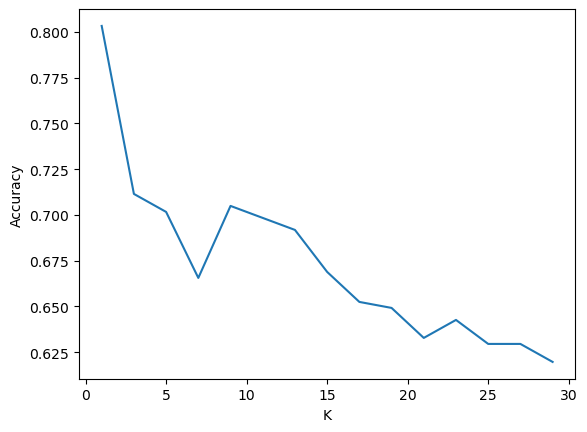

In [182]:
# PLotting K v/s accuracy graph
plt.plot(range(1,30,2), acc.values())
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [183]:
max_index = np.argmax(acc)

best_k = range(1, 30)[max_index]
print(best_k)

1


While k = 1 provides the highest accuracy level, it can result in over fitting.
It is recommended to select k values using uneven numbers as this results in a more balanced and unbiased classification.
Therefore, I decided to use k = 3.

In [184]:
# Selecting K = 3 
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

**(2) Random Forest**

https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

In [185]:
random_state=123

from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': list(range(1, 150)),
              'max_depth': [2, 4, 8, 12, 16, 20, None]}
grid = GridSearchCV(RandomForestClassifier(random_state=random_state,criterion='gini'), 
                    param_grid, cv=5) 
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=123),
             param_grid={'max_depth': [2, 4, 8, 12, 16, 20, None],
                         'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19, 20, 21,
                                          22, 23, 24, 25, 26, 27, 28, 29, 30, ...]})

In [186]:
grid.best_params_

{'max_depth': 20, 'n_estimators': 107}

In [187]:
output = grid.cv_results_

df = pd.DataFrame({
    'max_depth': [params['max_depth'] for params in output['params']],
    'n_estimators': [params['n_estimators'] for params in output['params']],
    'accuracy': output['mean_test_score']
})

In [188]:
print(df)

      max_depth  n_estimators  accuracy
0           2.0             1  0.613555
1           2.0             2  0.631905
2           2.0             3  0.602307
3           2.0             4  0.640376
4           2.0             5  0.619199
...         ...           ...       ...
1038        NaN           145  0.846209
1039        NaN           146  0.847618
1040        NaN           147  0.844791
1041        NaN           148  0.844791
1042        NaN           149  0.846199

[1043 rows x 3 columns]


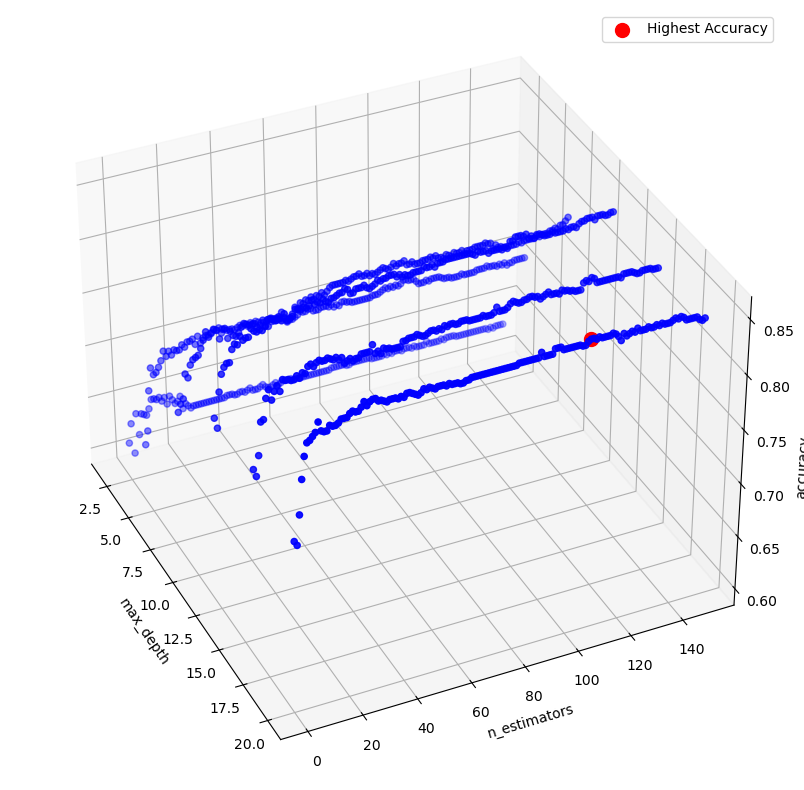

In [189]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.set_xlabel('max_depth')
ax.set_ylabel('n_estimators')
ax.set_zlabel('accuracy');

# plot the data (small blue circles) 
ax.scatter(df['max_depth'], df['n_estimators'], df['accuracy'],color='b') 

# Find the index of the maximum accuracy
best_param = df['accuracy'].idxmax()

# Highlight the point with the highest accuracy 
ax.scatter(df.loc[best_param, 'max_depth'], 
           df.loc[best_param, 'n_estimators'], 
           df.loc[best_param, 'accuracy'], 
           color='r', s=100, label='Highest Accuracy')
# set the viewing angle
ax.view_init(elev=35., azim=-25);
ax.legend()
plt.show()

In [190]:
clf = RandomForestClassifier(n_estimators=107, max_depth=20, random_state=random_state,criterion='gini')
clf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=20, n_estimators=107, random_state=123)

**(3)Model Evaluation and Comparative Analysis**



- Train and test your chosen algorithms using the training and testing sets.
- Evaluate the models using appropriate performance metrics (e.g., accuracy,  confusion matrix).
- Present the results, including any visualizations or graphs that help demonstrate performance differences.
- Compare both models' performances. Discuss whether the models provided similar or significantly different results and explain why.

https://www.statology.org/plot-roc-curve-python/

https://towardsdatascience.com/multiclass-classification-evaluation-with-roc-curves-and-roc-auc-294fd4617e3a

https://stackoverflow.com/questions/45332410/roc-for-multiclass-classification

In [191]:
# Target class names
target_names = ['low risk', 'mid risk', 'high risk']

Accuracy: 0.71
Precision: 0.71
Recall: 0.71
F1 Score: 0.71
ROC-AUC (One-vs-Rest): 0.8537838065654434
ROC-AUC (One-vs-One): 0.8558519793459552


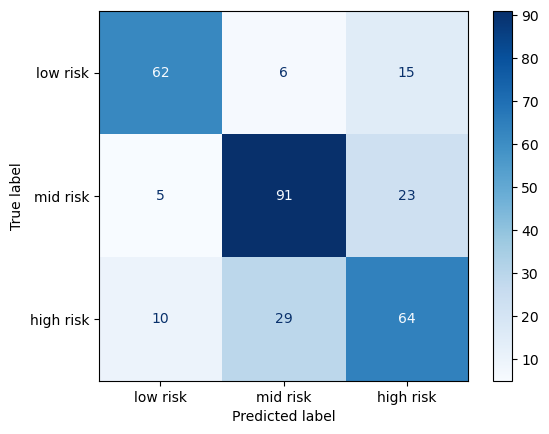

In [192]:
# KNN
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled) # required for ROC-AUC

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

roc_auc_ovr = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
roc_auc_ovo = roc_auc_score(y_test, y_pred_proba, multi_class='ovo')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'ROC-AUC (One-vs-Rest): {roc_auc_ovr}')
print(f'ROC-AUC (One-vs-One): {roc_auc_ovo}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Accuracy: 0.80
Precision: 0.80
Recall: 0.80
F1 Score: 0.80
ROC-AUC (One-vs-Rest): 0.9283586263972764
ROC-AUC (One-vs-One): 0.9308106211252779


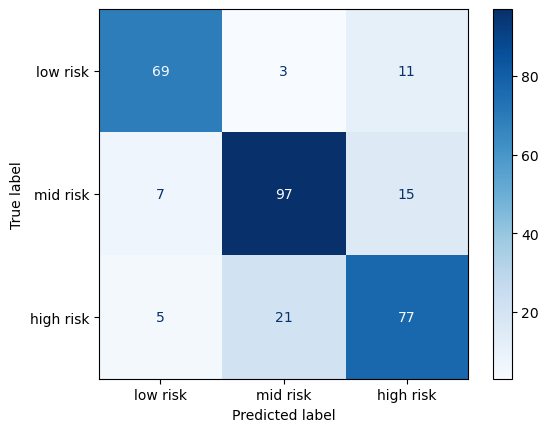

In [193]:
# Random Forest
y_pred = clf.predict(X_test_scaled)
y_pred_proba = clf.predict_proba(X_test_scaled) # required for ROC-AUC

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

roc_auc_ovr = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
roc_auc_ovo = roc_auc_score(y_test, y_pred_proba, multi_class='ovo')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'ROC-AUC (One-vs-Rest): {roc_auc_ovr}')
print(f'ROC-AUC (One-vs-One): {roc_auc_ovo}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()